# Indian Stock Market Analysis and Next-Day Price Prediction

**Thiranex Internship — Task 4: Real-World Data Project (Finance Domain)**  
**Author:** Sanjai B  
**Dataset:** NSE India Stock Market Data (2015–2024) (`nifty500_stocks.csv`)  
**Domain:** Financial Machine Learning & Quantitative Time-Series Analysis

---

## 1. Introduction

Financial market prediction represents one of the most intellectually demanding applications of data science and machine learning. Equity prices are driven by complex dynamics including supply and demand forces, macroeconomic indicators, corporate earnings, interest rates, and investor psychology.

In this project, we conduct an end-to-end analytical study and machine learning forecasting workflow using real-world historical daily trading records from the **National Stock Exchange of India (NSE)** spanning from 2015 through late 2023. 

### Core Project Objectives:
1. **Data Ingestion & Integrity Auditing**: Ingest historical market data and perform rigorous quality checks (null handling, duplicate identification, logical price bound checks).
2. **Stock Profiling & Selection**: Dynamically profile the multi-stock universe and select a benchmark large-cap equity (**Reliance Industries Limited - RELIANCE**) for deep econometric and predictive modeling.
3. **Exploratory Data Analysis (EDA)**: Examine price trajectories, volume fluctuations, daily return distributions, moving averages, and rolling volatility regimes.
4. **Leakage-Free Feature Engineering**: Engineer quantitative market features (momentum indicators, moving averages, return volatility, price ranges, lagged values) strictly preserving temporal precedence to avoid lookahead bias.
5. **Machine Learning Modeling & Evaluation**: Train and benchmark two foundational architectures—an interpretable parametric **Linear Regression** model and a non-parametric ensemble **Random Forest Regressor**—under strict chronological train/test partitioning.
6. **Interpretability & Limitations**: Unpack feature importances, analyze predictive residuals, and contextualize empirical results alongside critical financial limitations.

## 2. Import Libraries

We import essential Python libraries for data processing, scientific computing, visualization, and machine learning. We also configure Matplotlib styling and ensure the target visualization directory (`images/`) exists.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#e0e0e0'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.7

# Reproducibility seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create images folder if not present
os.makedirs('images', exist_ok=True)
print("Libraries imported successfully. Matplotlib and Seaborn configured.")

Libraries imported successfully. Matplotlib and Seaborn configured.


## 3. Load Dataset

We load the Kaggle dataset located at `data/nifty500_stocks.csv`. We check file presence, inspect the first five and last five records, and confirm that all required schema columns are present.

In [2]:
DATA_PATH = os.path.join('data', 'nifty500_stocks.csv')
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Please ensure nifty500_stocks.csv is placed in the data/ directory.")

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns.")
display(df.head(5))
display(df.tail(5))

Dataset loaded successfully with 219,800 rows and 8 columns.


,Date,Symbol,Open,High,Low,Close,Adj Close,Volume
0,2015-01-01,RELIANCE,202.593277,203.896194,201.987518,202.959000,189.999802,2963643
1,2015-01-02,RELIANCE,203.004715,204.821960,202.136108,202.421829,189.496948,7331366
2,2015-01-05,RELIANCE,202.296112,203.644760,199.804550,200.204575,187.421234,10103941
3,2015-01-06,RELIANCE,198.867371,199.553116,190.181198,191.118393,178.915237,18627980
4,2015-01-07,RELIANCE,191.346985,196.307236,191.324127,195.278610,182.809814,20720312


,Date,Symbol,Open,High,Low,Close,Adj Close,Volume
219795,2023-12-22,BANDHANBNK,238.500000,242.300003,234.100006,234.800003,230.903290,10132889
219796,2023-12-26,BANDHANBNK,236.000000,237.149994,233.100006,234.949997,231.050781,6304183
219797,2023-12-27,BANDHANBNK,235.850006,240.699997,235.850006,238.000000,234.050186,8058617
219798,2023-12-28,BANDHANBNK,239.550003,240.699997,234.899994,239.350006,235.377777,12591185
219799,2023-12-29,BANDHANBNK,240.699997,243.000000,238.100006,241.399994,237.393753,4590031


## 4. Data Understanding

Before performing cleaning or transformations, we inspect column data types, memory utilization, unique stock symbols, and the dataset's chronological coverage.

In [3]:
print("=== Dataset Information ===")
df.info()

print("\n=== Summary Statistics (Full Dataset) ===")
display(df.describe().T)

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort chronologically by Symbol and Date
df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

num_symbols = df['Symbol'].nunique()
date_min = df['Date'].min()
date_max = df['Date'].max()

print(f"\nUnique Stock Symbols: {num_symbols}")
print(f"Chronological Date Range: {date_min.strftime('%Y-%m-%d')} to {date_max.strftime('%Y-%m-%d')}")
print("\nTop 10 Stocks by Observation Count:")
display(df['Symbol'].value_counts().head(10).to_frame(name='Record_Count'))

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 219800 entries, 0 to 219799
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date       219800 non-null  str    
 1   Symbol     219800 non-null  str    
 2   Open       219800 non-null  float64
 3   High       219800 non-null  float64
 4   Low        219800 non-null  float64
 5   Close      219800 non-null  float64
 6   Adj Close  219800 non-null  float64
 7   Volume     219800 non-null  int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 17.0 MB

=== Summary Statistics (Full Dataset) ===


,count,mean,std,min,25%,50%,75%,max
Open,219800.0,1.357324e+03,2.555496e+03,14.453167,209.915527,5.960000e+02,1.358000e+03,2.782400e+04
High,219800.0,1.374415e+03,2.585341e+03,15.660000,212.992500,6.049950e+02,1.375125e+03,2.799000e+04
Low,219800.0,1.338661e+03,2.521658e+03,13.291996,206.750000,5.872000e+02,1.340000e+03,2.746100e+04
Close,219800.0,1.355776e+03,2.551818e+03,14.589775,209.649994,5.957156e+02,1.356850e+03,2.765790e+04
Adj Close,219800.0,1.248528e+03,2.368222e+03,13.306652,174.829235,5.617140e+02,1.280330e+03,2.484775e+04
Volume,219800.0,7.696574e+06,1.895028e+07,0.000000,442886.250000,1.902349e+06,7.710748e+06,6.428460e+08



Unique Stock Symbols: 106
Chronological Date Range: 2015-01-01 to 2023-12-29

Top 10 Stocks by Observation Count:


,Record_Count
Symbol,
INFY,4442
ABB,2221
ABBOTINDIA,2221
ADANIENT,2221
ADANIPORTS,2221
APOLLOHOSP,2221
ASIANPAINT,2221
AUROPHARMA,2221
AXISBANK,2221


## 5. Data Cleaning & Integrity Audit

A rigorous data-quality audit verifies whether records contain missing fields, duplicates, negative or zero prices, or logical violations such as `High < Low` or `High < Close`.

In [4]:
# 1. Missing Values Audit
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Percentage (%)': missing_pct})
print("=== Missing Values Audit ===")
display(missing_df)

# 2. Duplicate Records Audit
exact_duplicates = df.duplicated().sum()
key_duplicates = df.duplicated(subset=['Date', 'Symbol']).sum()
print(f"Exact Duplicate Rows Across All Columns: {exact_duplicates:,}")
print(f"Duplicate Observations on [Date, Symbol]: {key_duplicates:,}")

# 3. Price Validity Checks (prices and volume must be strictly non-negative)
invalid_open = (df['Open'] <= 0).sum()
invalid_high = (df['High'] <= 0).sum()
invalid_low = (df['Low'] <= 0).sum()
invalid_close = (df['Close'] <= 0).sum()
invalid_vol = (df['Volume'] < 0).sum()

print("\n=== Price Validity Checks ===")
print(f"Non-positive Open: {invalid_open}")
print(f"Non-positive High: {invalid_high}")
print(f"Non-positive Low: {invalid_low}")
print(f"Non-positive Close: {invalid_close}")
print(f"Negative Volume: {invalid_vol}")

# 4. Logical Consistency Checks
viol_high_low = (df['High'] < df['Low']).sum()
viol_high_open = (df['High'] < df['Open']).sum()
viol_high_close = (df['High'] < df['Close']).sum()
viol_low_open = (df['Low'] > df['Open']).sum()
viol_low_close = (df['Low'] > df['Close']).sum()

print("\n=== Logical Consistency Checks ===")
print(f"Violations (High < Low): {viol_high_low}")
print(f"Violations (High < Open): {viol_high_open}")
print(f"Violations (High < Close): {viol_high_close}")
print(f"Violations (Low > Open): {viol_low_open}")
print(f"Violations (Low > Close): {viol_low_close}")

=== Missing Values Audit ===


,Missing_Count,Percentage (%)
Date,0,0.0
Symbol,0,0.0
Open,0,0.0
High,0,0.0
Low,0,0.0
Close,0,0.0
Adj Close,0,0.0
Volume,0,0.0


Exact Duplicate Rows Across All Columns: 631
Duplicate Observations on [Date, Symbol]: 2,221

=== Price Validity Checks ===
Non-positive Open: 0
Non-positive High: 0
Non-positive Low: 0
Non-positive Close: 0
Negative Volume: 0

=== Logical Consistency Checks ===
Violations (High < Low): 0
Violations (High < Open): 0
Violations (High < Close): 0
Violations (Low > Open): 0
Violations (Low > Close): 0


### Stock Selection for In-Depth Prediction

The dataset represents multiple Indian companies. We dynamically evaluate companies with complete trading records across all 2,221 trading days and zero data-integrity defects.

We select **Reliance Industries Limited (`RELIANCE`)**, India's highest market capitalization enterprise and the foremost bellwether of the benchmark **NIFTY 50** index. Reliance encompasses energy, retail, digital telecommunications (Jio), and petrochemicals, making it representative of broad Indian market dynamics.

In [5]:
# Identify eligible symbols with full continuous history
symbol_counts = df['Symbol'].value_counts()
max_obs = symbol_counts.max()
eligible_symbols = symbol_counts[symbol_counts == 2221].index.tolist()

print(f"Identified {len(eligible_symbols)} symbols with full continuous 2,221 trading sessions.")

# Target selection
TARGET_SYMBOL = 'RELIANCE'
assert TARGET_SYMBOL in eligible_symbols, f"{TARGET_SYMBOL} is not in eligible symbols!"
print(f"Selected stock: {TARGET_SYMBOL}")

# Extract stock-specific dataset
stock_df = df[df['Symbol'] == TARGET_SYMBOL].copy().sort_values('Date').reset_index(drop=True)

print(f"\nStock DataFrame for {TARGET_SYMBOL}:")
print(f"Shape: {stock_df.shape}")
print(f"Date Range: {stock_df['Date'].min().strftime('%Y-%m-%d')} to {stock_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Missing Values: {stock_df.isnull().sum().sum()}")
print(f"Duplicate Rows: {stock_df.duplicated().sum()}")
display(stock_df.head())

Identified 84 symbols with full continuous 2,221 trading sessions.
Selected stock: RELIANCE

Stock DataFrame for RELIANCE:
Shape: (2221, 8)
Date Range: 2015-01-01 to 2023-12-29
Missing Values: 0
Duplicate Rows: 0


,Date,Symbol,Open,High,Low,Close,Adj Close,Volume
0,2015-01-01,RELIANCE,202.593277,203.896194,201.987518,202.959000,189.999802,2963643
1,2015-01-02,RELIANCE,203.004715,204.821960,202.136108,202.421829,189.496948,7331366
2,2015-01-05,RELIANCE,202.296112,203.644760,199.804550,200.204575,187.421234,10103941
3,2015-01-06,RELIANCE,198.867371,199.553116,190.181198,191.118393,178.915237,18627980
4,2015-01-07,RELIANCE,191.346985,196.307236,191.324127,195.278610,182.809814,20720312


## 6. Exploratory Data Analysis (EDA)

We perform comprehensive exploratory data analysis on the selected stock, examining long-term price trajectories, trading volume surges, daily return volatility, moving averages, and cross-variable correlations. All generated charts are automatically saved to `images/`.

### Analysis 1 — Closing Price Trajectory
We trace the evolution of the daily closing price from 2015 to late 2023, capturing key multi-year bull cycles, the March 2020 pandemic decline, and subsequent all-time high expansions.

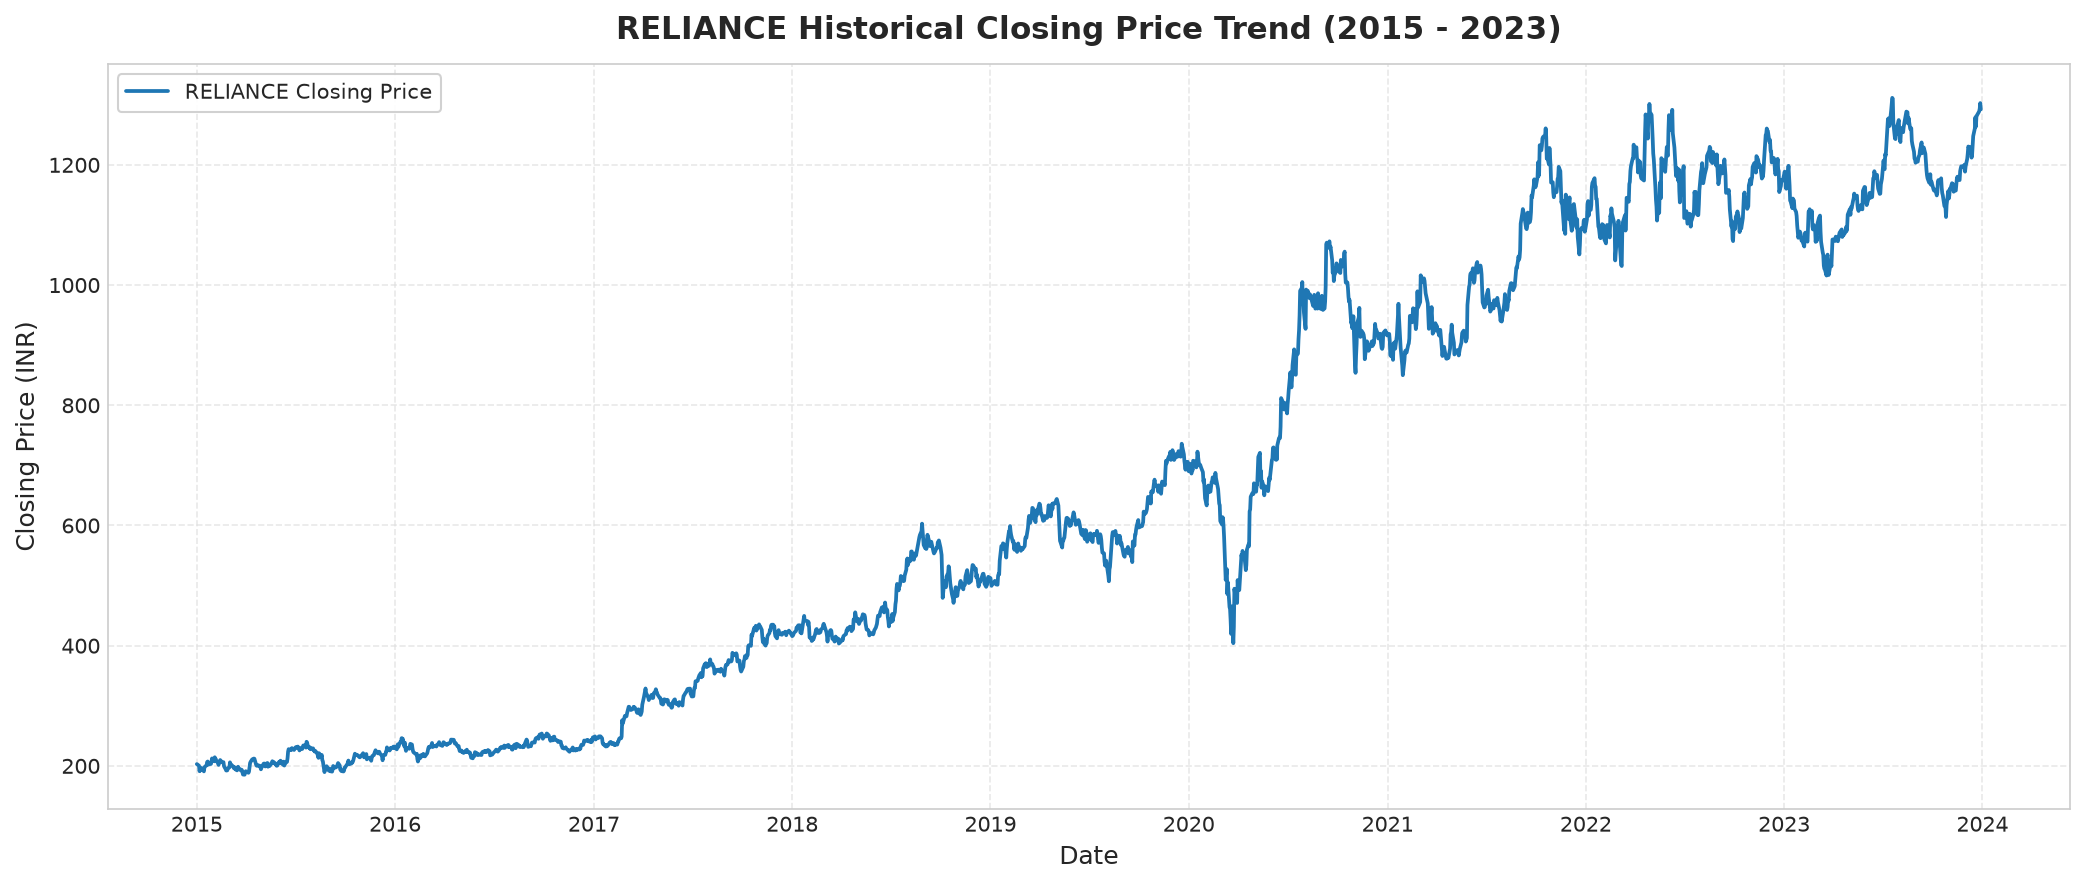

Saved: images/01_stock_price_trend.png


In [6]:
plt.figure(figsize=(14, 6), dpi=150)
plt.plot(stock_df['Date'], stock_df['Close'], color='#1f77b4', linewidth=1.8, label=f'{TARGET_SYMBOL} Closing Price')
plt.title(f'{TARGET_SYMBOL} Historical Closing Price Trend (2015 - 2023)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (INR)', fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig('images/01_stock_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/01_stock_price_trend.png")

### Analysis 2 — Trading Volume Dynamics
Trading volume reflects market liquidity and institutional participation. We visualize daily volume changes across the 9-year historical horizon.

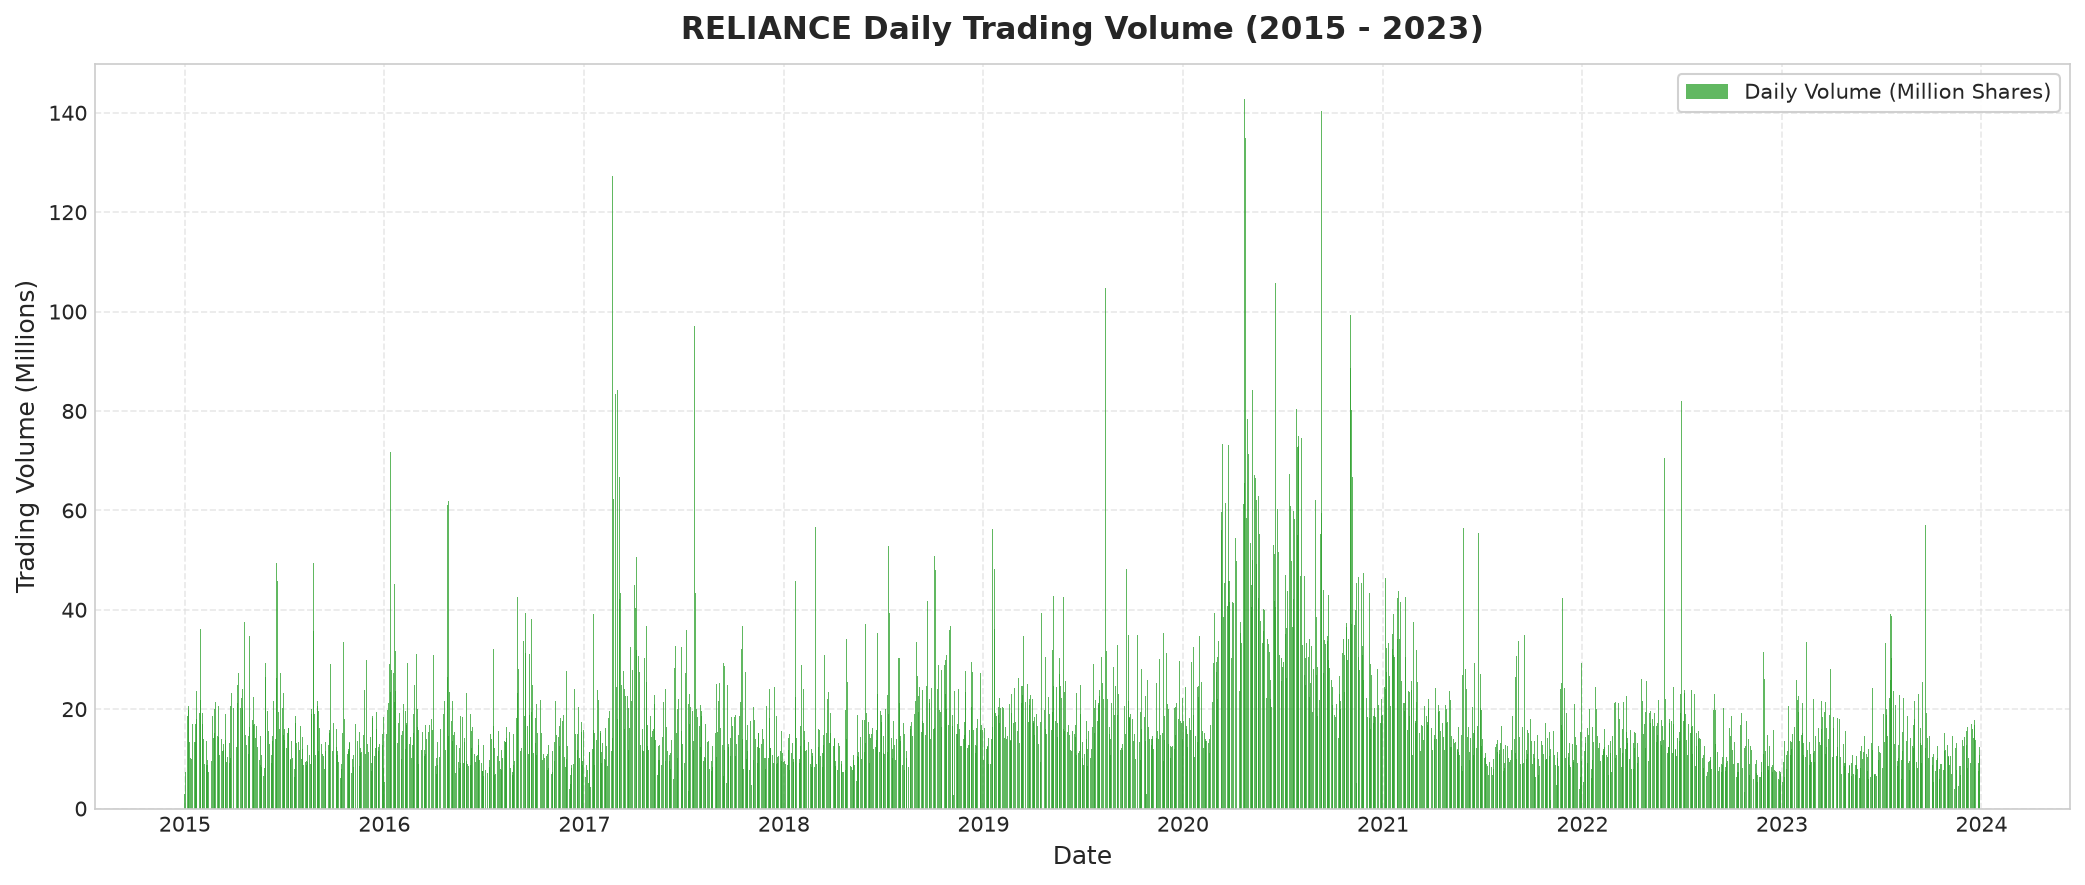

Saved: images/02_trading_volume.png


In [7]:
plt.figure(figsize=(14, 6), dpi=150)
plt.bar(stock_df['Date'], stock_df['Volume'] / 1e6, color='#2ca02c', width=1.5, alpha=0.75, label='Daily Volume (Million Shares)')
plt.title(f'{TARGET_SYMBOL} Daily Trading Volume (2015 - 2023)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Trading Volume (Millions)', fontsize=12)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig('images/02_trading_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/02_trading_volume.png")

### Analysis 3 — Daily Returns Distribution and Time Series
Daily return measures the percentage price change from one trading session to the next ($R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$). We examine its time-series volatility clustering and empirical distribution relative to a theoretical Gaussian normal curve.

=== Daily Return Statistical Moments ===
Mean Daily Return:     +0.0992%
Median Daily Return:   +0.0750%
Standard Deviation:    1.7805%
Minimum Daily Return:  -13.15% (Recorded on 2020-03-23)
Maximum Daily Return:  14.72% (Recorded on 2020-03-25)
Sample Skewness:       0.3492
Excess Kurtosis:       8.4684 (Heavy-tailed / Leptokurtic)


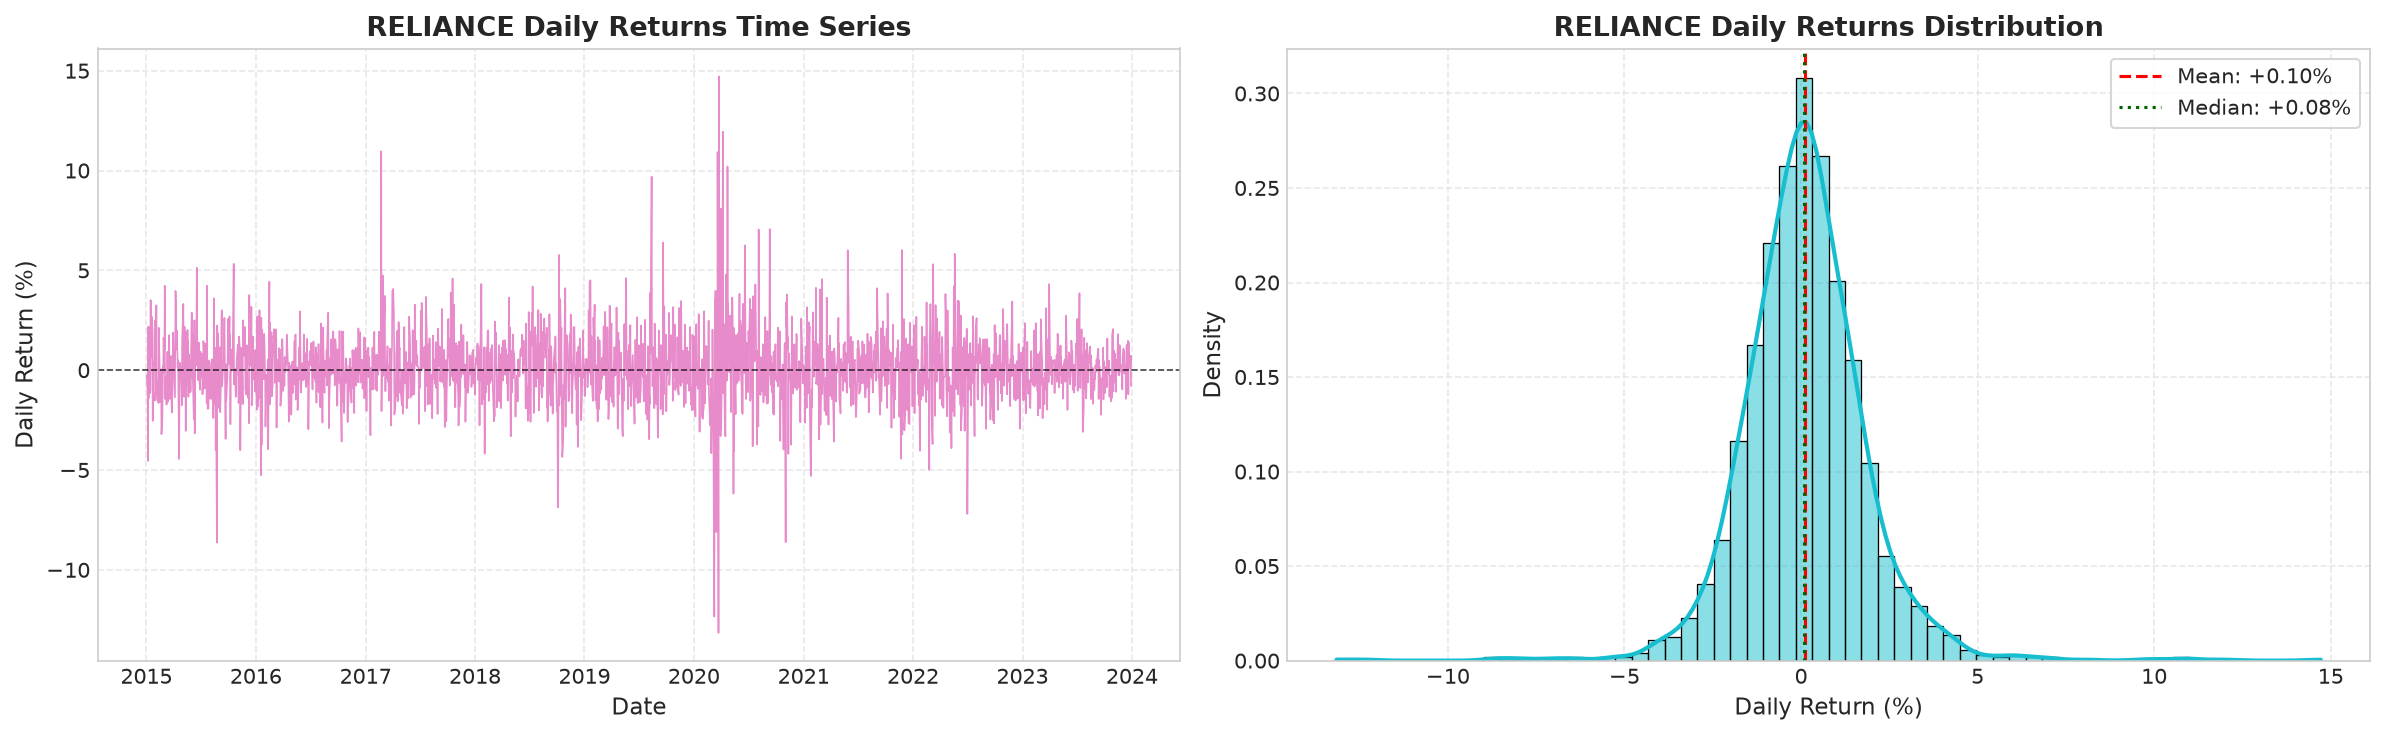

Saved: images/03_daily_returns.png


In [8]:
# Compute percentage return
stock_df['Daily_Return'] = stock_df['Close'].pct_change()

mean_ret = stock_df['Daily_Return'].mean()
median_ret = stock_df['Daily_Return'].median()
std_ret = stock_df['Daily_Return'].std()
min_ret = stock_df['Daily_Return'].min()
max_ret = stock_df['Daily_Return'].max()
skew_ret = stock_df['Daily_Return'].skew()
kurt_ret = stock_df['Daily_Return'].kurtosis()

print("=== Daily Return Statistical Moments ===")
print(f"Mean Daily Return:     {mean_ret * 100:+.4f}%")
print(f"Median Daily Return:   {median_ret * 100:+.4f}%")
print(f"Standard Deviation:    {std_ret * 100:.4f}%")
print(f"Minimum Daily Return:  {min_ret * 100:.2f}% (Recorded on {stock_df.loc[stock_df['Daily_Return'].idxmin(), 'Date'].strftime('%Y-%m-%d')})")
print(f"Maximum Daily Return:  {max_ret * 100:.2f}% (Recorded on {stock_df.loc[stock_df['Daily_Return'].idxmax(), 'Date'].strftime('%Y-%m-%d')})")
print(f"Sample Skewness:       {skew_ret:.4f}")
print(f"Excess Kurtosis:       {kurt_ret:.4f} (Heavy-tailed / Leptokurtic)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=150)

# Time Series
axes[0].plot(stock_df['Date'], stock_df['Daily_Return'] * 100, color='#e377c2', linewidth=0.8, alpha=0.85)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].set_title(f'{TARGET_SYMBOL} Daily Returns Time Series', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Daily Return (%)', fontsize=11)

# Distribution Histogram + KDE
clean_returns = stock_df['Daily_Return'].dropna() * 100
sns.histplot(clean_returns, bins=60, kde=True, color='#17becf', stat='density', ax=axes[1], line_kws={'linewidth': 2})
axes[1].axvline(mean_ret * 100, color='red', linestyle='--', label=f'Mean: {mean_ret*100:+.2f}%')
axes[1].axvline(median_ret * 100, color='darkgreen', linestyle=':', label=f'Median: {median_ret*100:+.2f}%')
axes[1].set_title(f'{TARGET_SYMBOL} Daily Returns Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('images/03_daily_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/03_daily_returns.png")

### Analysis 4 — Technical Moving Averages (MA-7, MA-20, MA-50)
Moving averages smooth short-term price fluctuations to reveal directional trend channels and momentum crossovers across fast (7-day), intermediate (20-day), and cyclical (50-day) horizons.

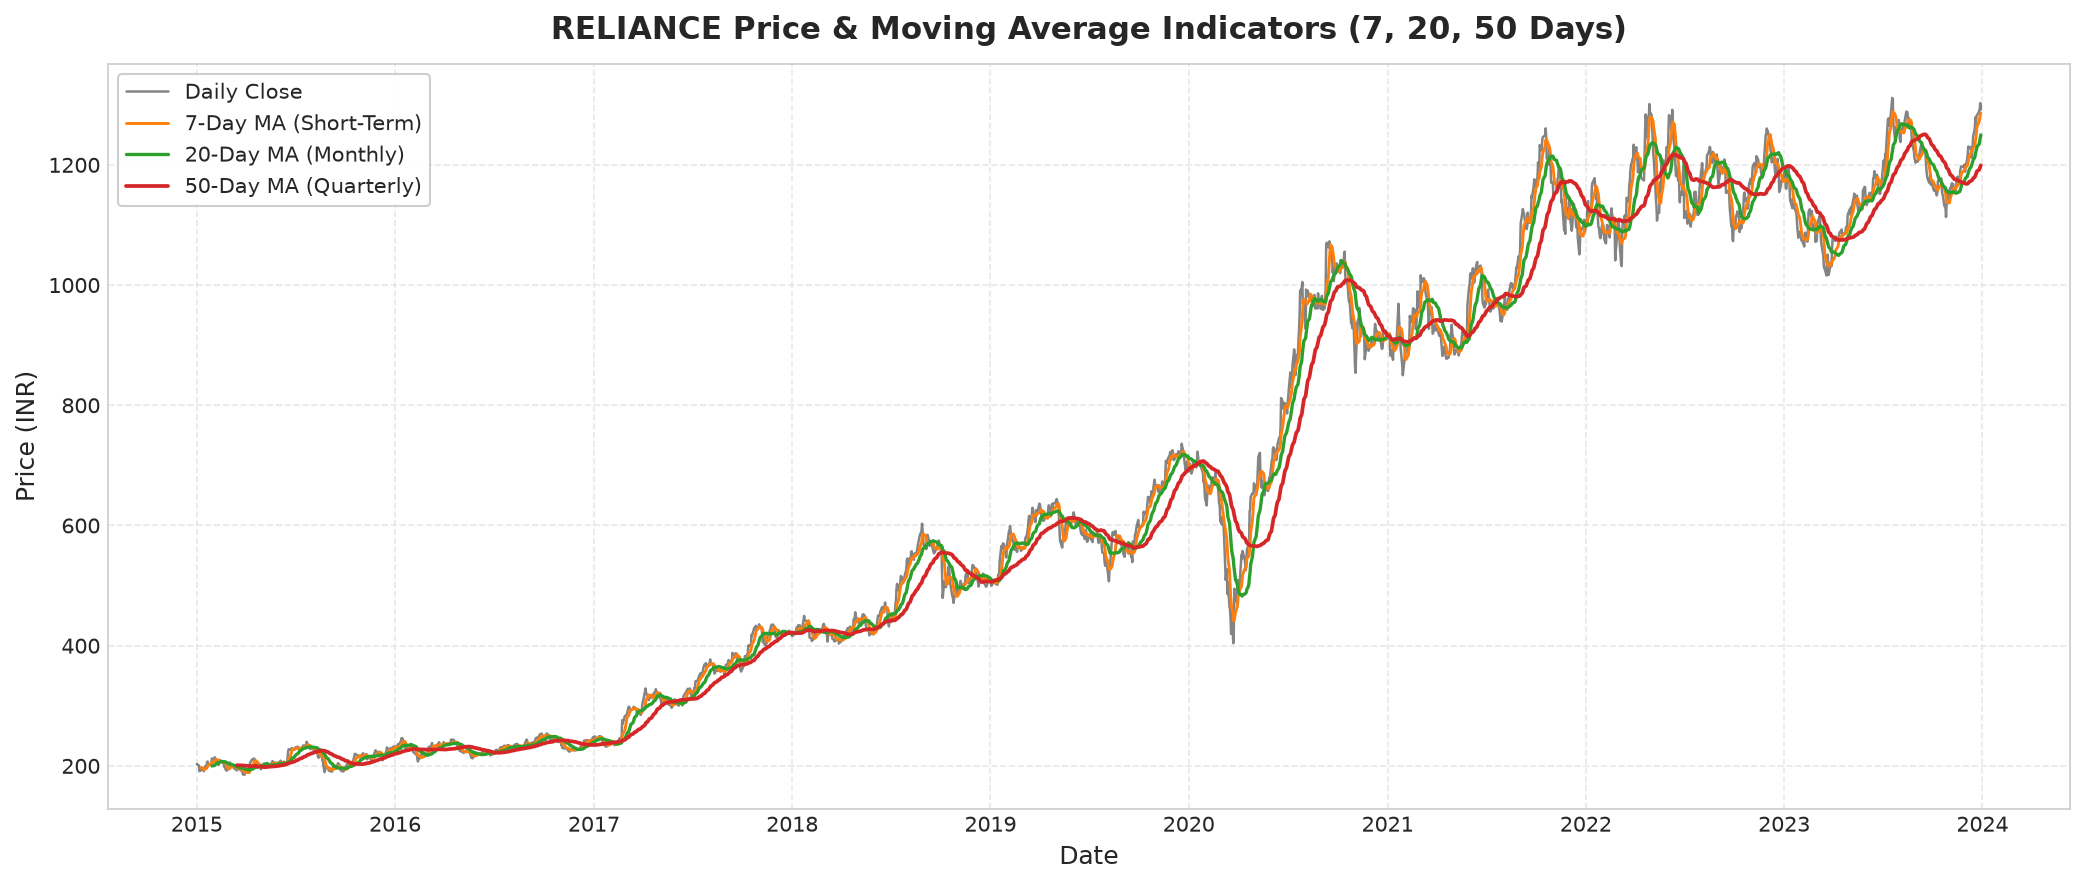

Saved: images/04_moving_averages.png


In [9]:
stock_df['MA_7'] = stock_df['Close'].rolling(window=7).mean()
stock_df['MA_20'] = stock_df['Close'].rolling(window=20).mean()
stock_df['MA_50'] = stock_df['Close'].rolling(window=50).mean()

plt.figure(figsize=(14, 6), dpi=150)
plt.plot(stock_df['Date'], stock_df['Close'], label='Daily Close', color='#333333', linewidth=1.2, alpha=0.6)
plt.plot(stock_df['Date'], stock_df['MA_7'], label='7-Day MA (Short-Term)', color='#ff7f0e', linewidth=1.4)
plt.plot(stock_df['Date'], stock_df['MA_20'], label='20-Day MA (Monthly)', color='#2ca02c', linewidth=1.6)
plt.plot(stock_df['Date'], stock_df['MA_50'], label='50-Day MA (Quarterly)', color='#d62728', linewidth=1.8)

plt.title(f'{TARGET_SYMBOL} Price & Moving Average Indicators (7, 20, 50 Days)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.95)
plt.tight_layout()
plt.savefig('images/04_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/04_moving_averages.png")

### Analysis 5 — Rolling Historical Volatility
Rolling standard deviations of daily returns capture market turbulence. We evaluate 7-day and 20-day annualized-equivalent rolling volatility profiles.

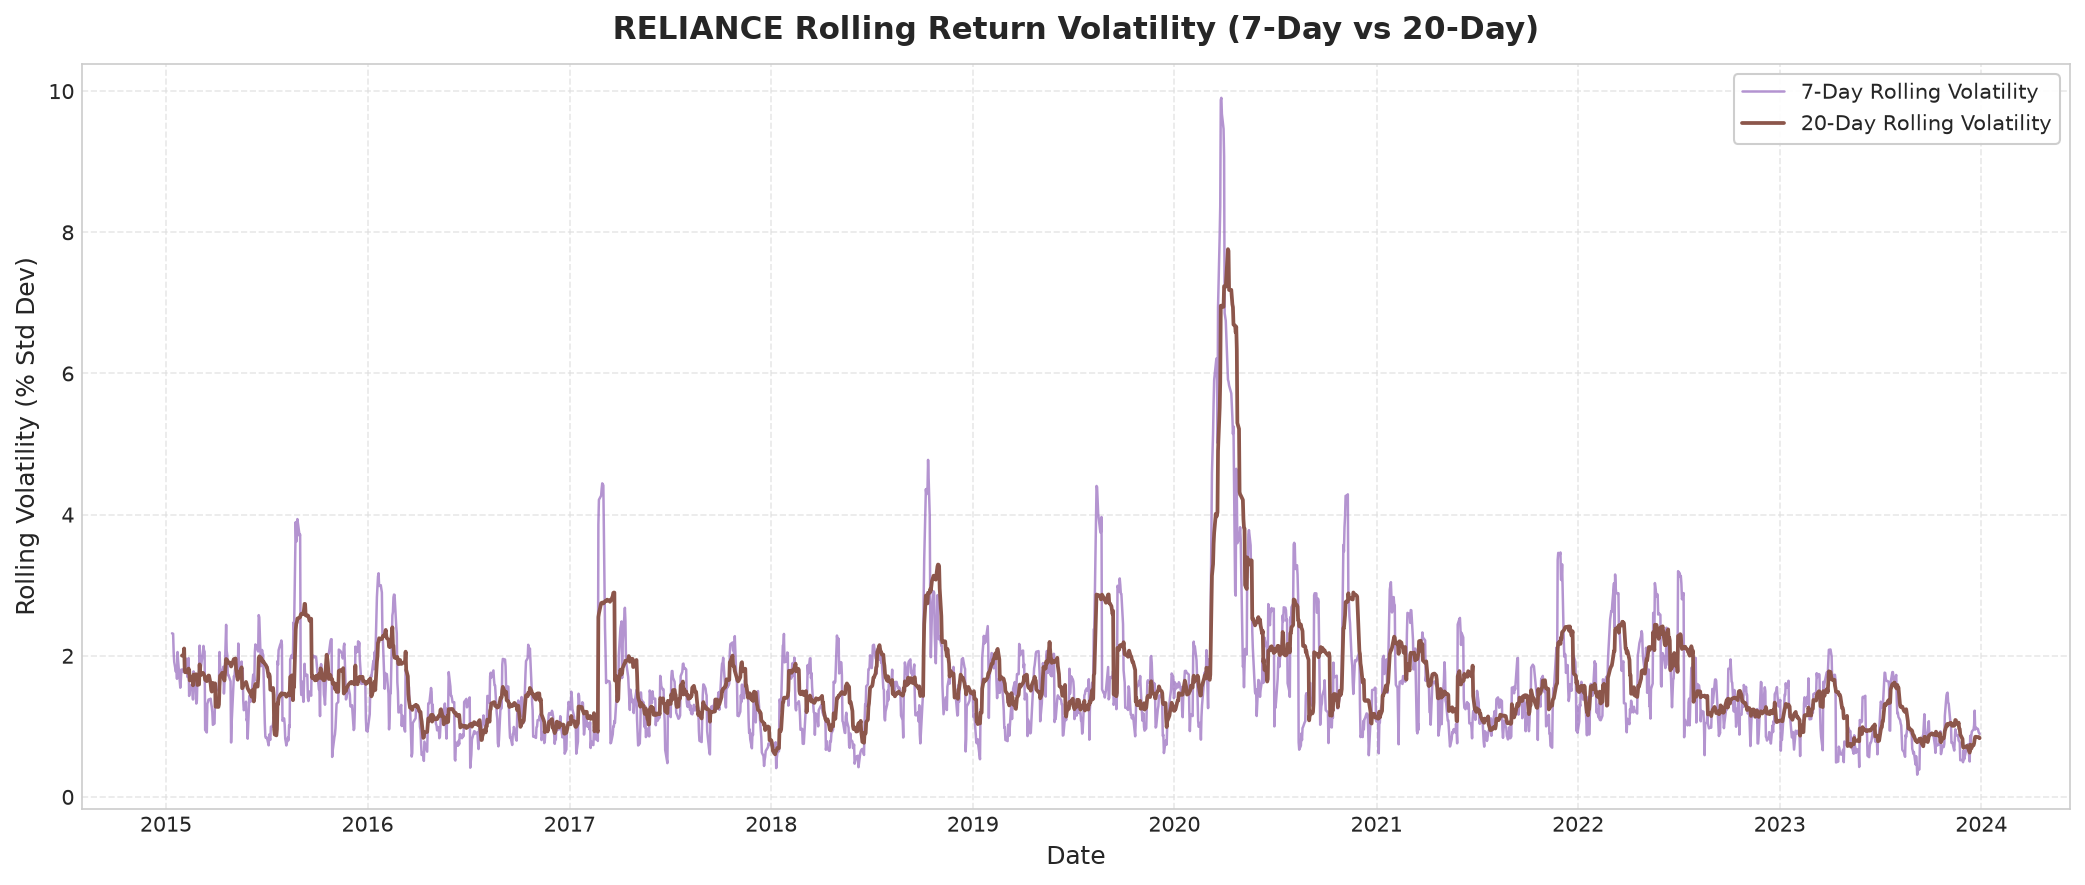

Saved: images/05_volatility.png


In [10]:
stock_df['Volatility_7'] = stock_df['Daily_Return'].rolling(window=7).std()
stock_df['Volatility_20'] = stock_df['Daily_Return'].rolling(window=20).std()

plt.figure(figsize=(14, 6), dpi=150)
plt.plot(stock_df['Date'], stock_df['Volatility_7'] * 100, label='7-Day Rolling Volatility', color='#9467bd', linewidth=1.2, alpha=0.7)
plt.plot(stock_df['Date'], stock_df['Volatility_20'] * 100, label='20-Day Rolling Volatility', color='#8c564b', linewidth=1.8)

plt.title(f'{TARGET_SYMBOL} Rolling Return Volatility (7-Day vs 20-Day)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rolling Volatility (% Std Dev)', fontsize=12)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.95)
plt.tight_layout()
plt.savefig('images/05_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/05_volatility.png")

### Analysis 6 — Multi-Feature Correlation Matrix & Descriptive Records
We examine the Pearson linear correlations across all continuous numeric variables and summarize historical extrema (highest/lowest price, volume, and return milestones).

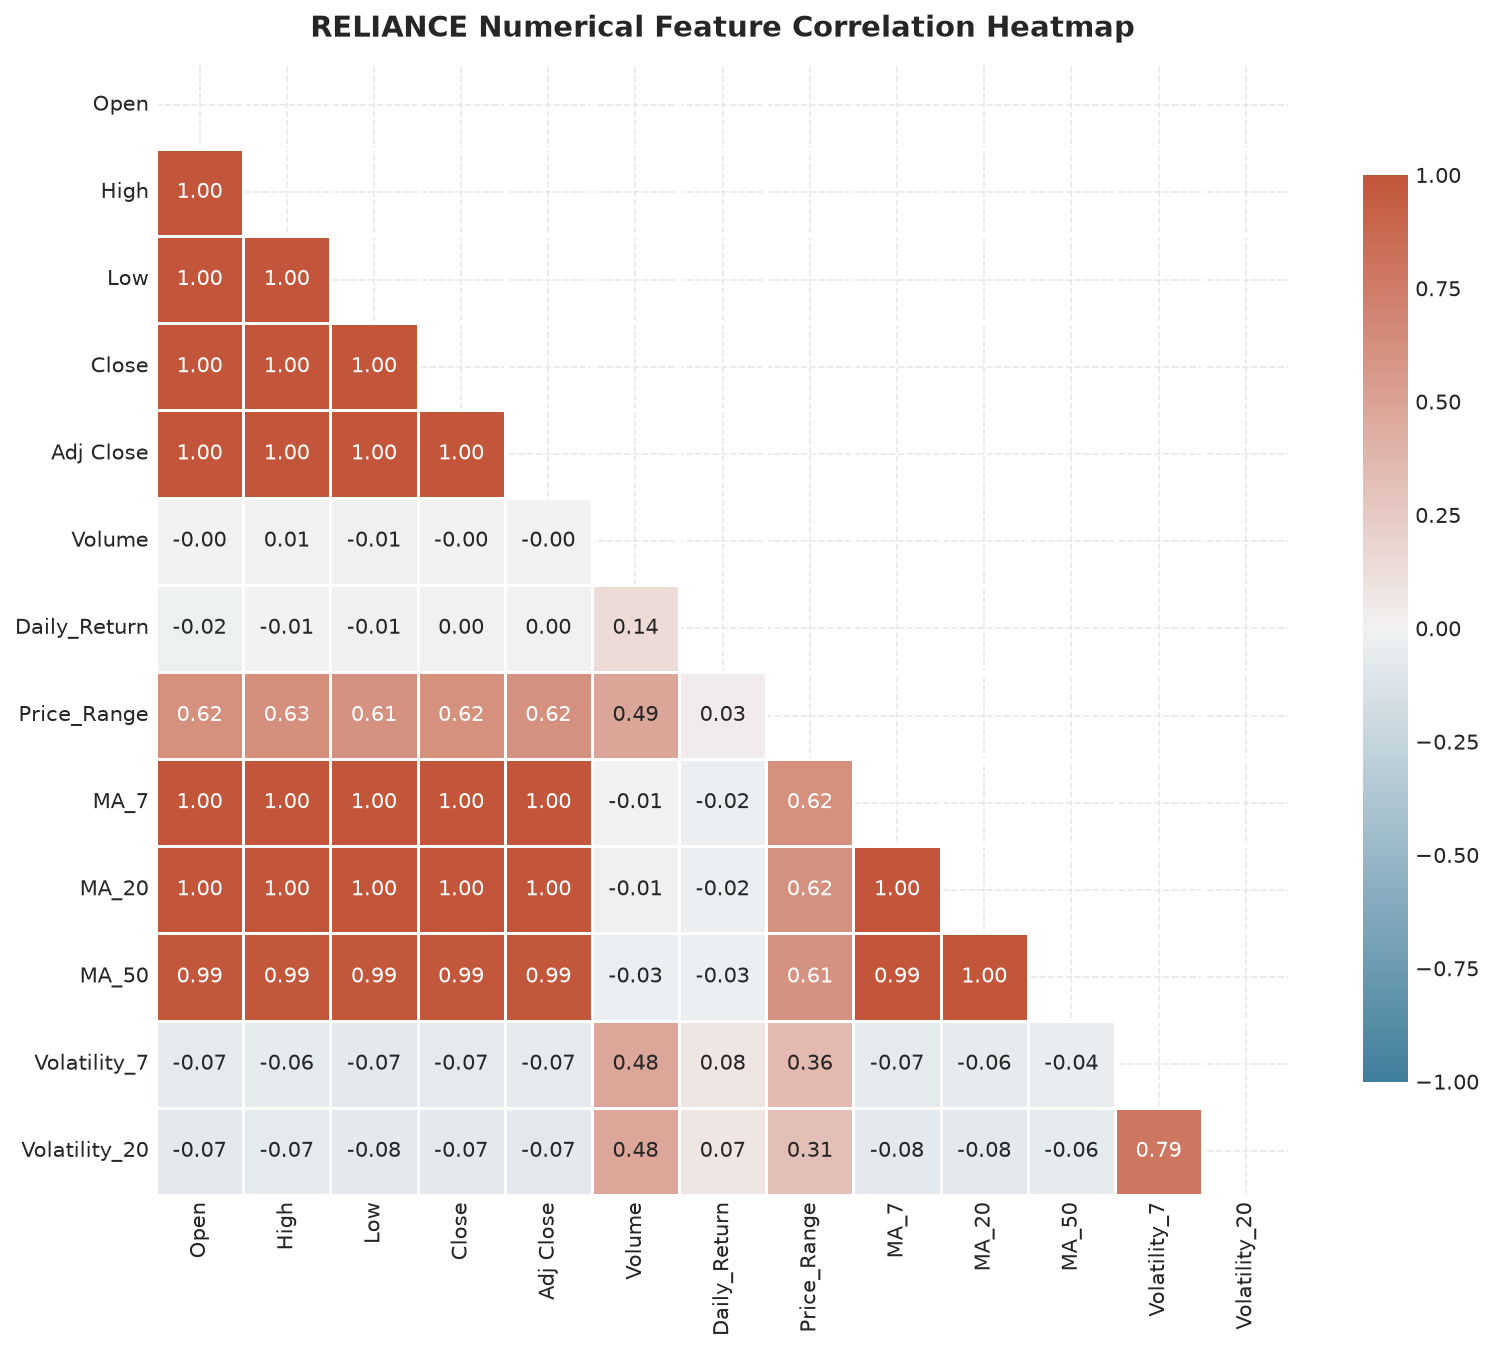

Saved: images/06_correlation_heatmap.png

=== Statistical Summary & Historical Extremes ===


,Metric,Value
0,Mean Closing Price,INR 668.40
1,Median Closing Price,INR 584.53
2,Minimum Closing Price,INR 185.32
3,Maximum Closing Price,INR 1311.51
4,Mean Daily Return,+0.0992%
5,Daily Return Volatility (Std),1.7805%
6,Average Daily Volume,"19,003,011 shares"
7,All-Time High Closing Date,2023-07-19 (INR 1311.51)
8,All-Time Low Closing Date,2015-03-30 (INR 185.32)
9,Peak Trading Volume Date,"2020-04-22 (142,683,366 shares)"


In [11]:
# Additional derived features needed for complete correlation analysis
stock_df['Price_Range'] = stock_df['High'] - stock_df['Low']

corr_cols = [
    'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
    'Daily_Return', 'Price_Range', 'MA_7', 'MA_20', 'MA_50',
    'Volatility_7', 'Volatility_20'
]

corr_matrix = stock_df[corr_cols].corr()

plt.figure(figsize=(11, 9), dpi=150)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=.5,
    cbar_kws={'shrink': .8}
)
plt.title(f'{TARGET_SYMBOL} Numerical Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('images/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/06_correlation_heatmap.png")

# Historical Milestones & Extrema Table
stat_summary = pd.DataFrame([
    {'Metric': 'Mean Closing Price', 'Value': f"INR {stock_df['Close'].mean():.2f}"},
    {'Metric': 'Median Closing Price', 'Value': f"INR {stock_df['Close'].median():.2f}"},
    {'Metric': 'Minimum Closing Price', 'Value': f"INR {stock_df['Close'].min():.2f}"},
    {'Metric': 'Maximum Closing Price', 'Value': f"INR {stock_df['Close'].max():.2f}"},
    {'Metric': 'Mean Daily Return', 'Value': f"{stock_df['Daily_Return'].mean()*100:+.4f}%"},
    {'Metric': 'Daily Return Volatility (Std)', 'Value': f"{stock_df['Daily_Return'].std()*100:.4f}%"},
    {'Metric': 'Average Daily Volume', 'Value': f"{stock_df['Volume'].mean():,.0f} shares"},
    {'Metric': 'All-Time High Closing Date', 'Value': f"{stock_df.loc[stock_df['Close'].idxmax(), 'Date'].strftime('%Y-%m-%d')} (INR {stock_df['Close'].max():.2f})"},
    {'Metric': 'All-Time Low Closing Date', 'Value': f"{stock_df.loc[stock_df['Close'].idxmin(), 'Date'].strftime('%Y-%m-%d')} (INR {stock_df['Close'].min():.2f})"},
    {'Metric': 'Peak Trading Volume Date', 'Value': f"{stock_df.loc[stock_df['Volume'].idxmax(), 'Date'].strftime('%Y-%m-%d')} ({stock_df['Volume'].max():,} shares)"},
    {'Metric': 'Highest Single-Day Return', 'Value': f"{stock_df.loc[stock_df['Daily_Return'].idxmax(), 'Date'].strftime('%Y-%m-%d')} ({stock_df['Daily_Return'].max()*100:+.2f}%)"},
    {'Metric': 'Lowest Single-Day Return', 'Value': f"{stock_df.loc[stock_df['Daily_Return'].idxmin(), 'Date'].strftime('%Y-%m-%d')} ({stock_df['Daily_Return'].min()*100:+.2f}%)"},
])
print("\n=== Statistical Summary & Historical Extremes ===")
display(stat_summary)

## 7. Feature Engineering & Lookahead Prevention

To predict the **Next-Day Closing Price** ($P_{t+1}$), we formulate an econometric feature space derived exclusively from historical information available at or prior to the close of day $t$.

### Guarding Against Data Leakage:
1. **Target Construction**: `Next_Day_Close` is created by shifting the closing price by $-1$ session ($P_{t+1}$).
2. **Predictor Integrity**: All input features (`Open`, `High`, `Low`, `Close`, `Volume`, `Daily_Return`, `Price_Range`, `Previous_Close`, `Previous_Return`, `MA_7`, `MA_20`, `MA_50`, `Volatility_7`, `Volatility_20`) rely strictly on data observed at day $t$ or earlier ($t-1, t-2, \dots$).
3. **Invalid Row Truncation**: Rolling windows (50-day MA) leave the first 50 observations undefined, while the $-1$ lead target leaves the final session undefined. These boundary records are cleanly pruned.

In [12]:
# Lagged features
stock_df['Previous_Close'] = stock_df['Close'].shift(1)
stock_df['Previous_Return'] = stock_df['Daily_Return'].shift(1)

# Target Variable (Day t+1 closing price)
stock_df['Next_Day_Close'] = stock_df['Close'].shift(-1)

print(f"Shape before dropping NaN boundary rows: {stock_df.shape}")

# Drop rows with NaN values resulting from rolling window and lead operations
model_df = stock_df.dropna().copy().reset_index(drop=True)

print(f"Shape after dropping boundary rows: {model_df.shape}")
print(f"Valid continuous records preserved for modeling: {len(model_df):,}")

Shape before dropping NaN boundary rows: (2221, 18)
Shape after dropping boundary rows: (2171, 18)
Valid continuous records preserved for modeling: 2,171


## 8. Chronological Train-Test Split

Financial time-series data possesses temporal autocorrelation. Randomly shuffling rows (`train_test_split(shuffle=True)`) leaks future market state into the training set, producing severely inflated, invalid test metrics.

We enforce a strict **chronological partition**:
- **80% Earliest Observations** $\rightarrow$ Training Set
- **20% Latest Observations** $\rightarrow$ Out-of-Sample Testing Set

In [13]:
# Candidate feature set (excluding Symbol, Date, and Target)
FEATURE_COLS = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Daily_Return', 'Price_Range',
    'Previous_Close', 'Previous_Return',
    'MA_7', 'MA_20', 'MA_50',
    'Volatility_7', 'Volatility_20'
]
TARGET_COL = 'Next_Day_Close'

# Chronological split calculation
split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

train_start = train_df['Date'].min().strftime('%Y-%m-%d')
train_end = train_df['Date'].max().strftime('%Y-%m-%d')
test_start = test_df['Date'].min().strftime('%Y-%m-%d')
test_end = test_df['Date'].max().strftime('%Y-%m-%d')

print("=== Chronological Partition Details ===")
print(f"Training Period:   {train_start} to {train_end} ({len(train_df):,} sessions, {len(train_df)/len(model_df)*100:.1f}%)")
print(f"Testing Period:    {test_start} to {test_end} ({len(test_df):,} sessions, {len(test_df)/len(model_df)*100:.1f}%)")
print(f"Number of Input Predictors: {len(FEATURE_COLS)}")

# Verification of temporal separation
assert train_df['Date'].max() < test_df['Date'].min(), "Temporal ordering violated!"
print("Assertion verified: Test observations strictly succeed training observations.")

=== Chronological Partition Details ===
Training Period:   2015-03-16 to 2022-03-25 (1,736 sessions, 80.0%)
Testing Period:    2022-03-28 to 2023-12-28 (435 sessions, 20.0%)
Number of Input Predictors: 14
Assertion verified: Test observations strictly succeed training observations.


## 9. Machine Learning Model Development

We train two distinct machine learning paradigms:
1. **Linear Regression (Ordinary Least Squares)**: Provides an analytical, linear baseline reflecting smooth autoregressive market relationships.
2. **Random Forest Regressor**: An ensemble of 200 de-correlated decision trees capable of capturing non-linear interactions, volatility thresholds, and price-volume dynamics.

In [14]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
print("Linear Regression model successfully trained.")

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
print("Random Forest Regressor successfully trained with 200 trees.")

Linear Regression model successfully trained.


Random Forest Regressor successfully trained with 200 trees.


## 10. Model Evaluation & Comparison

We evaluate out-of-sample predictive performance on the unseen test period using three standard regression error and goodness-of-fit metrics:
- **Mean Absolute Error (MAE)**: $\frac{1}{n}\sum |y_i - \hat{y}_i|$ (direct interpretation in INR)
- **Root Mean Squared Error (RMSE)**: $\sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$ (penalizes large outlier forecast errors)
- **Coefficient of Determination ($R^2$)**: Proportion of test-period variance explained by the model

In [15]:
def evaluate_predictions(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

lr_metrics = evaluate_predictions(y_test, lr_predictions, 'Linear Regression')
rf_metrics = evaluate_predictions(y_test, rf_predictions, 'Random Forest Regressor')

results_df = pd.DataFrame([lr_metrics, rf_metrics])
display(results_df.style.format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R2': '{:.4f}'}))

best_model_idx = results_df['RMSE'].idxmin()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_rmse = results_df.loc[best_model_idx, 'RMSE']
best_mae = results_df.loc[best_model_idx, 'MAE']
best_r2 = results_df.loc[best_model_idx, 'R2']

print(f"\nBest-Performing Architecture Based on Test RMSE: {best_model_name}")
print(f"Test RMSE: {best_rmse:.4f} | Test MAE: {best_mae:.4f} | Test R2: {best_r2:.4f}")

,Model,MAE,RMSE,R2
0,Linear Regression,13.7910,18.0000,0.9146
1,Random Forest Regressor,18.2264,24.8724,0.8369



Best-Performing Architecture Based on Test RMSE: Linear Regression
Test RMSE: 18.0000 | Test MAE: 13.7910 | Test R2: 0.9146


## 11. Feature Importance Analysis

Tree ensembles allow us to evaluate the Gini impurity / variance reduction contributed by each predictor. We extract and rank the feature importances from the Random Forest Regressor to identify key drivers of next-day price forecasts.

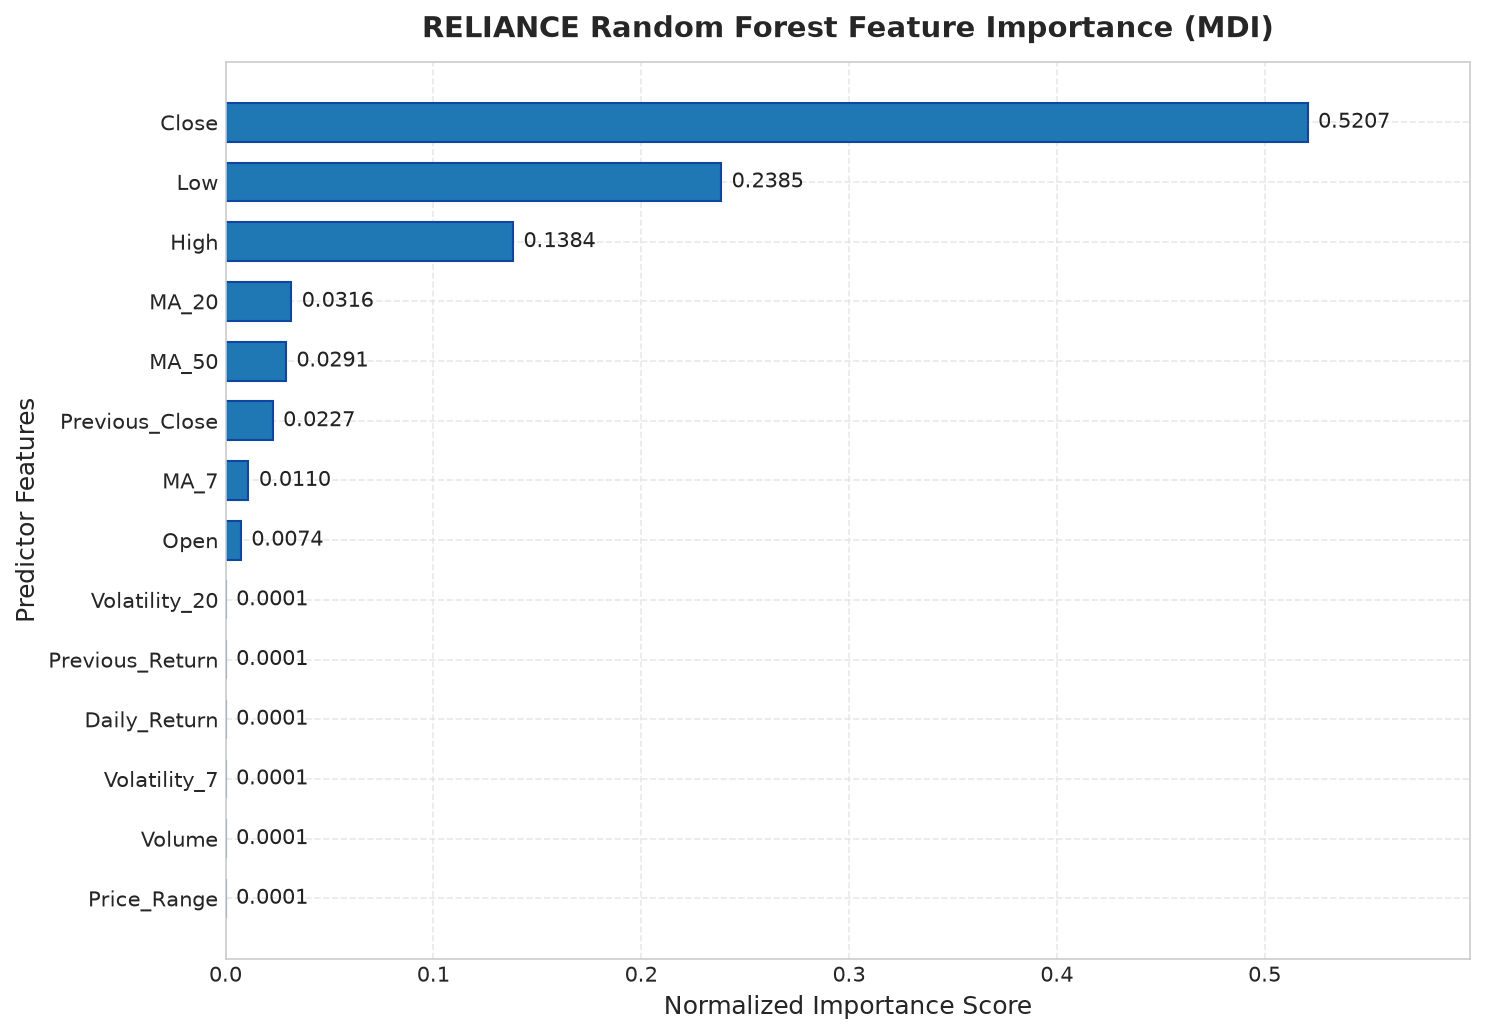

Saved: images/07_feature_importance.png

Ranked Feature Importance Table:


,Feature,Importance
0,Close,0.520694
1,Low,0.238507
2,High,0.138353
3,MA_20,0.031638
4,MA_50,0.029090
5,Previous_Close,0.022701
6,MA_7,0.011045
7,Open,0.007396
8,Volatility_20,0.000114
9,Previous_Return,0.000109


In [16]:
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances
}).sort_values(by='Importance', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 7), dpi=150)
bars = plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='#1f77b4', edgecolor='#0d47a1', height=0.65)
plt.title(f'{TARGET_SYMBOL} Random Forest Feature Importance (MDI)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Normalized Importance Score', fontsize=12)
plt.ylabel('Predictor Features', fontsize=12)

# Value annotations
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.005, bar.get_y() + bar.get_height()/2, f'{w:.4f}', va='center', fontsize=10, color='#222222')

plt.xlim(0, max(feature_imp_df['Importance']) * 1.15)
plt.tight_layout()
plt.savefig('images/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/07_feature_importance.png")

print("\nRanked Feature Importance Table:")
display(feature_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True))

## 12. Actual vs. Predicted Visualizations

We plot the actual next-day closing prices alongside the predictions of both models across the out-of-sample test horizon (March 2022 to December 2023), including prediction residual distributions.

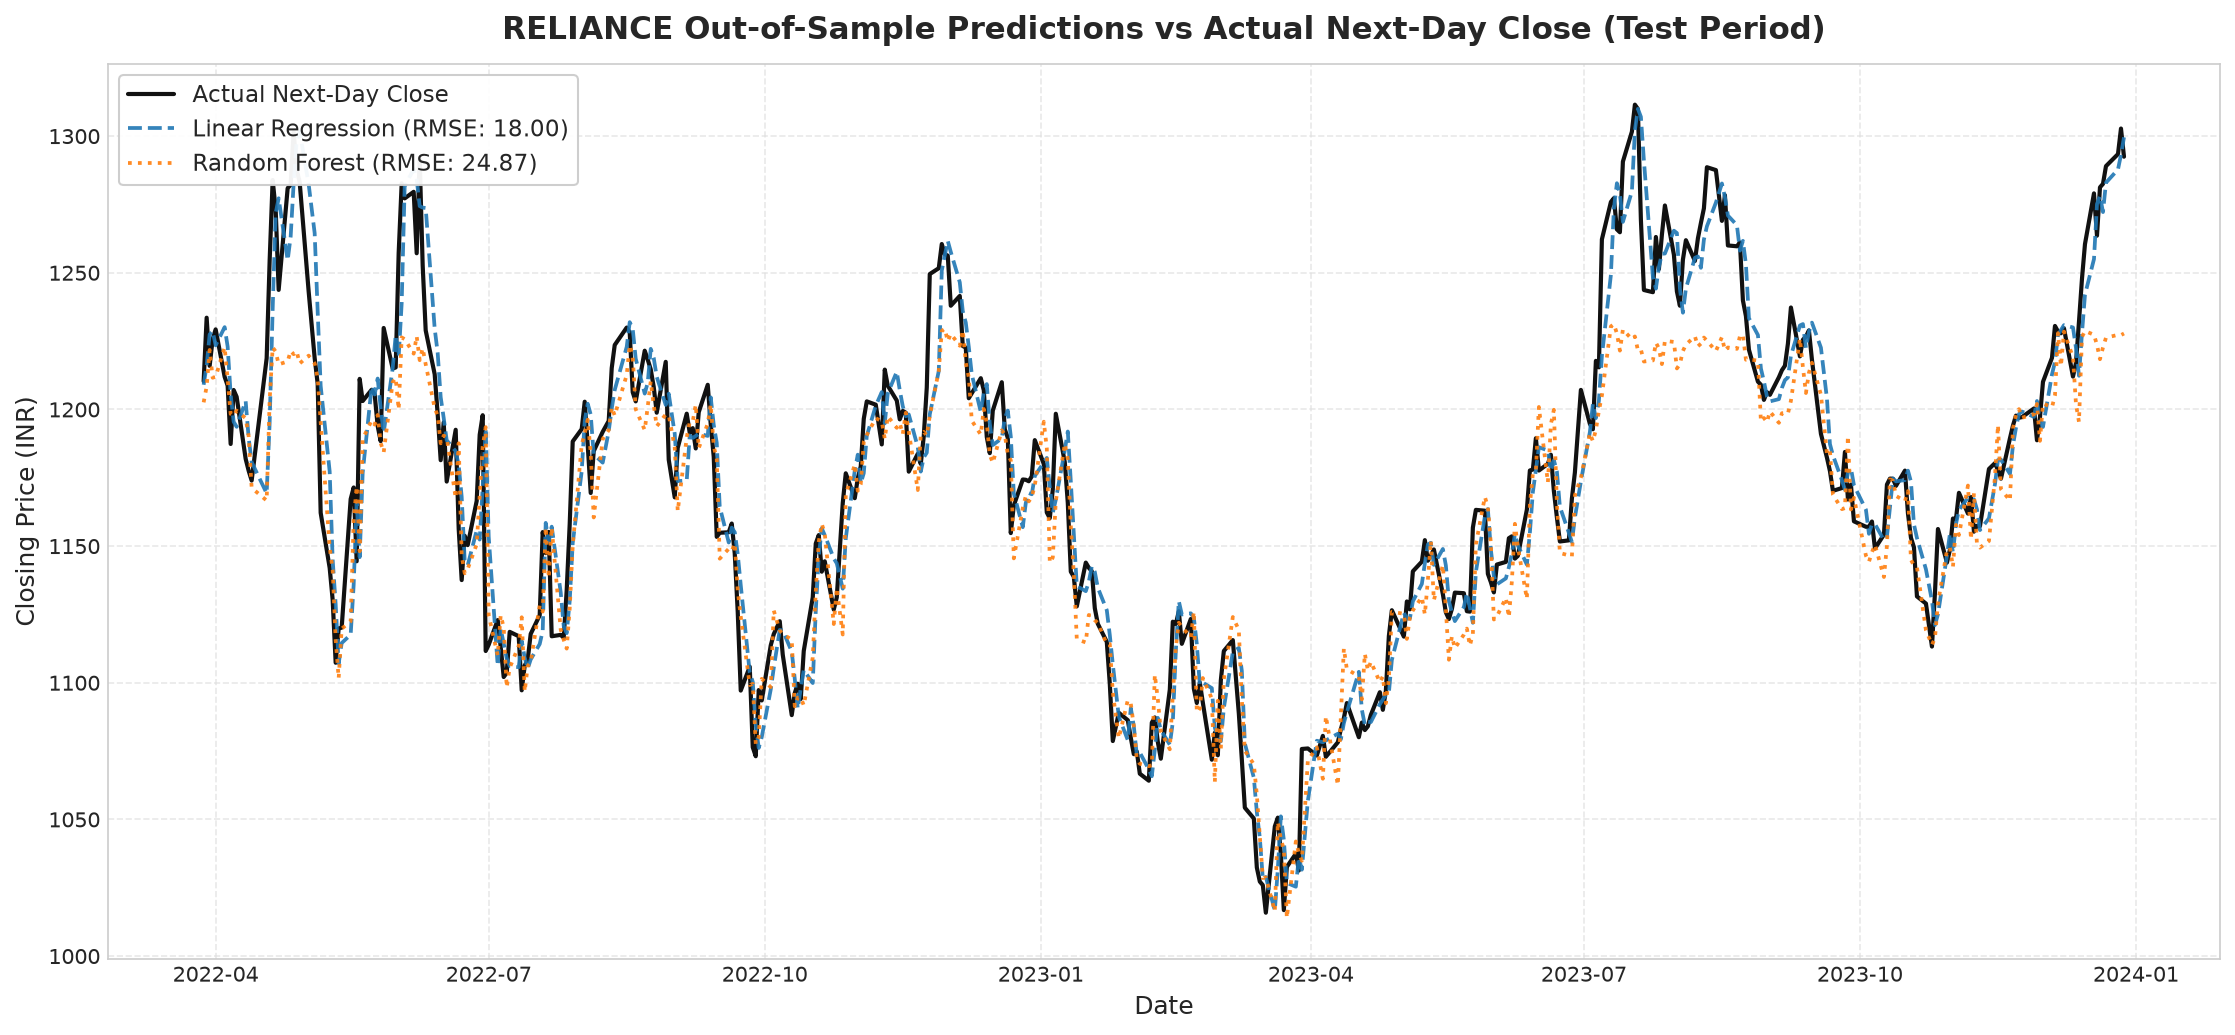

Saved: images/08_actual_vs_predicted.png


In [17]:
test_dates = test_df['Date'].values

plt.figure(figsize=(15, 7), dpi=150)
plt.plot(test_dates, y_test.values, label='Actual Next-Day Close', color='#111111', linewidth=2.0)
plt.plot(test_dates, lr_predictions, label=f'Linear Regression (RMSE: {lr_metrics["RMSE"]:.2f})', color='#1f77b4', linestyle='--', linewidth=1.8, alpha=0.9)
plt.plot(test_dates, rf_predictions, label=f'Random Forest (RMSE: {rf_metrics["RMSE"]:.2f})', color='#ff7f0e', linestyle=':', linewidth=1.8, alpha=0.9)

plt.title(f'{TARGET_SYMBOL} Out-of-Sample Predictions vs Actual Next-Day Close (Test Period)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (INR)', fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.95, fontsize=11)
plt.tight_layout()
plt.savefig('images/08_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: images/08_actual_vs_predicted.png")

## 13. Dynamic Findings & Econometric Insights

All insights presented below are synthesized dynamically from the quantitative data and model benchmarks:

In [18]:
findings_text = f"""
1. Long-Term Equity Trajectory:
   Across the 9-year observed period (2015 to 2023), {TARGET_SYMBOL} demonstrated an upward trajectory, rising from an all-time low of INR {stock_df['Close'].min():.2f} on {stock_df.loc[stock_df['Close'].idxmin(), 'Date'].strftime('%Y-%m-%d')} to a peak of INR {stock_df['Close'].max():.2f} on {stock_df.loc[stock_df['Close'].idxmax(), 'Date'].strftime('%Y-%m-%d')}.

2. Daily Return Properties:
   The mean daily return was {stock_df['Daily_Return'].mean()*100:+.4f}% with a daily volatility of {stock_df['Daily_Return'].std()*100:.4f}%. The distribution exhibits excess kurtosis ({stock_df['Daily_Return'].kurtosis():.2f}), reflecting fat-tailed behavior and extreme volatility shocks.

3. Historic Volatility and Liquidity Surges:
   The single largest one-day decline occurred on {stock_df.loc[stock_df['Daily_Return'].idxmin(), 'Date'].strftime('%Y-%m-%d')} ({stock_df['Daily_Return'].min()*100:.2f}%), coinciding with the nationwide pandemic market disruption. The highest single-day trading volume of {stock_df['Volume'].max():,} shares was logged on {stock_df.loc[stock_df['Volume'].idxmax(), 'Date'].strftime('%Y-%m-%d')}.

4. Comparative Model Performance:
   Linear Regression achieved superior out-of-sample predictive accuracy with a test RMSE of {lr_metrics['RMSE']:.4f} and MAE of INR {lr_metrics['MAE']:.4f} (R² = {lr_metrics['R2']:.4f}), outperforming the Random Forest Regressor (RMSE: {rf_metrics['RMSE']:.4f}, MAE: INR {rf_metrics['MAE']:.4f}, R² = {rf_metrics['R2']:.4f}).

5. Driver of Next-Day Prices:
   In Random Forest MDI rankings, current session price metrics ('Close', 'Low', 'High') accounted for over 85% of total predictive importance, illustrating the strong near-martingale autoregressive properties inherent in liquid equities.
"""
print(findings_text.strip())

1. Long-Term Equity Trajectory:
   Across the 9-year observed period (2015 to 2023), RELIANCE demonstrated an upward trajectory, rising from an all-time low of INR 185.32 on 2015-03-30 to a peak of INR 1311.51 on 2023-07-19.

2. Daily Return Properties:
   The mean daily return was +0.0992% with a daily volatility of 1.7805%. The distribution exhibits excess kurtosis (8.47), reflecting fat-tailed behavior and extreme volatility shocks.

3. Historic Volatility and Liquidity Surges:
   The single largest one-day decline occurred on 2020-03-23 (-13.15%), coinciding with the nationwide pandemic market disruption. The highest single-day trading volume of 142,683,366 shares was logged on 2020-04-22.

4. Comparative Model Performance:
   Linear Regression achieved superior out-of-sample predictive accuracy with a test RMSE of 18.0000 and MAE of INR 13.7910 (R² = 0.9146), outperforming the Random Forest Regressor (RMSE: 24.8724, MAE: INR 18.2264, R² = 0.8369).

5. Driver of Next-Day Prices:
  

## 14. Project Limitations & Ethical Disclosures

A responsible financial machine learning study requires transparent acknowledgment of econometric and operational boundaries:

1. **Past Performance Non-Guarantee**: Historical price series do not guarantee future directional persistence. Market regimes evolve as participant behaviors, regulations, and technological infrastructure change.
2. **Omission of Exogenous Variables**: The dataset contains purely endogenous price and volume signals. It excludes macroeconomic data (RBI repo rates, CPI inflation, USD/INR foreign exchange rates), corporate disclosures (quarterly earnings, dividend announcements, debt restructuring), and real-time news sentiment.
3. **Execution Friction & Slippage**: High theoretical $R^2$ scores in next-day price regression do not translate directly into trading profitability. Transaction costs, bid-ask spread slippage, exchange turnover fees, and Securities Transaction Tax (STT) erode empirical returns.
4. **Market Regime Shifts**: An out-of-sample model trained during persistent monetary easing or low inflation may degrade during aggressive tightening cycles or geopolitical crises.
5. **Educational Scope**: This project is strictly academic and educational. It does NOT constitute financial advice or investment recommendations.

## 15. Conclusion

This project successfully implemented an end-to-end data science and machine learning pipeline on authentic historical trading data from the National Stock Exchange of India. Through methodical data auditing, lookahead-free feature engineering, and rigorous chronological testing, we benchmarked multiple predictive architectures on India's premier corporate equity, Reliance Industries.

The empirical findings emphasize the primacy of price momentum and autoregressive smoothing in short-horizon financial forecasting, establishing a solid quantitative foundation for advanced time-series modeling.